# Disaster Tweets

**Competição:** https://www.kaggle.com/competitions/nlp-getting-started  
**Autora:** Juliana Burato  
**Algoritmo:** Word2Vec + Feature Engineering + Ensemble (Voting Classifier)  
**F1-Score no Kaggle:** 0.80324

---

## Descrição

Classificação binária de tweets: desastre real (1) ou não (0).  
O dataset contém 7.613 tweets de treino com texto, keyword e localização.

## Fluxo

```
train.csv / test.csv
    → EDA e visualização
    → Limpeza e pré-processamento do texto
    → Tokenização + Word2Vec (embeddings 200d, 20 epochs)
    → Feature engineering (metadados + keyword encoded)
    → Concatenação: embeddings + features manuais
    → Ensemble: Logistic Regression + SVM + Random Forest (soft voting)
    → submission.csv
```

## 1. Imports

In [1]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

np.random.seed(42)

## 2. Dados

| Arquivo | Linhas | Colunas |
|---|---|---|
| `train.csv` | 7.613 | 5 (id, keyword, location, text, target) |
| `test.csv` | 3.263 | 4 (id, keyword, location, text) |

**Upload no Colab:** ícone de pasta → upload → `train.csv` e `test.csv`

In [3]:
train = pd.read_csv('/content/train.csv')
test  = pd.read_csv('/content/test.csv')

print(f'train: {train.shape}')
print(f'test:  {test.shape}')
train.head()

train: (7613, 5)
test:  (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 3. Análise Exploratória

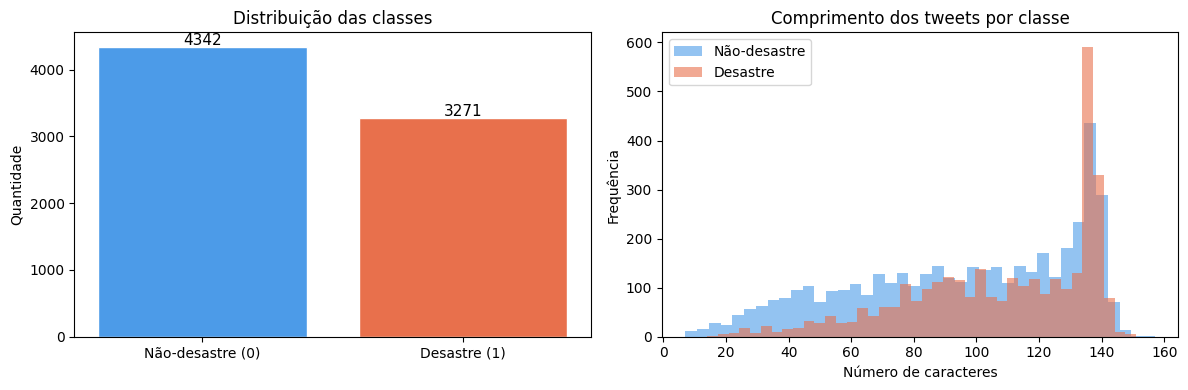

In [4]:
# Distribuição das classes — leve desbalanceamento (43% desastre, 57% não-desastre)
# Não requer oversampling, mas o F1-score é mais adequado que acurácia como métrica
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contagem = train['target'].value_counts()
axes[0].bar(['Não-desastre (0)', 'Desastre (1)'], contagem.values,
            color=['#4C9BE8', '#E8704C'], edgecolor='white')
axes[0].set_title('Distribuição das classes')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11)

# Tweets de desastre tendem a ser mais longos — comprimento será usada como feature
train['text_len'] = train['text'].apply(len)
axes[1].hist(train[train['target']==0]['text_len'], bins=40, alpha=0.6,
             color='#4C9BE8', label='Não-desastre')
axes[1].hist(train[train['target']==1]['text_len'], bins=40, alpha=0.6,
             color='#E8704C', label='Desastre')
axes[1].set_title('Comprimento dos tweets por classe')
axes[1].set_xlabel('Número de caracteres')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

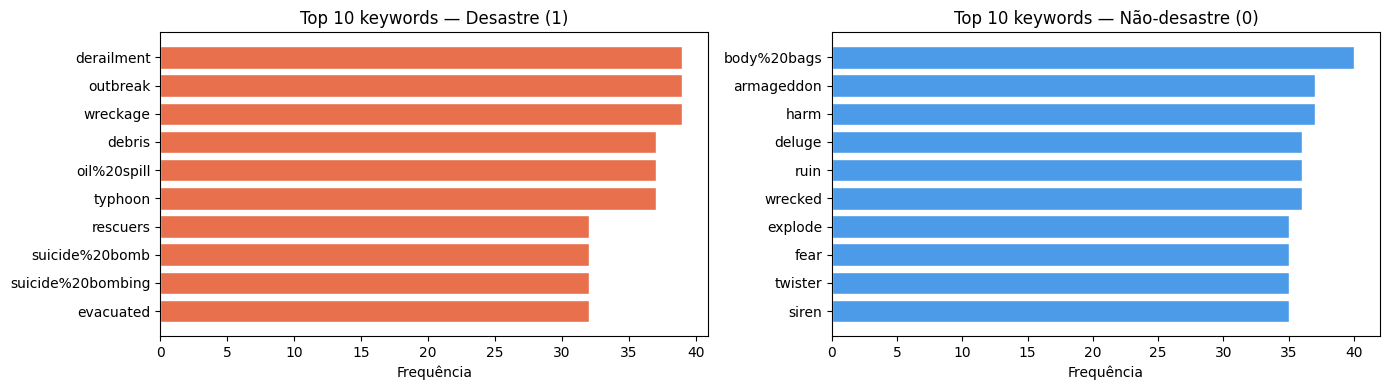

In [5]:
# Keywords mais associadas a desastres reais vs. não-desastres
# A keyword é uma das features mais preditivas do dataset — palavras como
# 'earthquake' e 'flood' já indicam fortemente a classe correta
top_desastre     = (train[train['target']==1]['keyword']
                    .value_counts().head(10))
top_nao_desastre = (train[train['target']==0]['keyword']
                    .value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(top_desastre.index[::-1], top_desastre.values[::-1],
             color='#E8704C', edgecolor='white')
axes[0].set_title('Top 10 keywords — Desastre (1)')
axes[0].set_xlabel('Frequência')

axes[1].barh(top_nao_desastre.index[::-1], top_nao_desastre.values[::-1],
             color='#4C9BE8', edgecolor='white')
axes[1].set_title('Top 10 keywords — Não-desastre (0)')
axes[1].set_xlabel('Frequência')

plt.tight_layout()
plt.show()

In [6]:
# Valores ausentes — keyword (61 nulos) e location (2.533 nulos); text é completo
print('Valores nulos — treino:')
print(train.isnull().sum())

Valores nulos — treino:
id             0
keyword       61
location    2533
text           0
target         0
text_len       0
dtype: int64


## 4. Pré-processamento

Etapas aplicadas ao texto de cada tweet:

| Etapa | Descrição | Justificativa |
|---|---|---|
| URLs | Remoção de `http://...` | Não carregam significado semântico |
| Menções | Remoção de `@usuario` | Ruído sem valor preditivo |
| Hashtags | Mantém o texto, remove `#` | O conteúdo da hashtag é relevante |
| Lowercasing | Converte para minúsculas | Unifica tokens (`Fire` = `fire`) |
| Pontuação | Remoção de caracteres especiais | Reduz vocabulário sem perda semântica |
| Stopwords | Remoção de palavras funcionais | Reduz ruído; foco em palavras de conteúdo |
| Lematização | Reduz palavras à forma base | `burning → burn`, `fires → fire` |

In [7]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def limpar_texto(texto):
    texto = re.sub(r'http\S+|www\S+', '', texto)          # remove URLs
    texto = re.sub(r'@\w+', '', texto)                     # remove menções
    texto = re.sub(r'#', '', texto)                        # mantém texto das hashtags
    texto = texto.lower()                                  # lowercasing
    texto = re.sub(r'[^a-z\s]', '', texto)                 # remove pontuação e números
    tokens = word_tokenize(texto)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]       # stopwords + tokens muito curtos
    return tokens

train['tokens'] = train['text'].apply(limpar_texto)
test['tokens']  = test['text'].apply(limpar_texto)

# Exemplo de tweet antes e depois do pré-processamento
idx = 10
print('Original: ', train['text'].iloc[idx])
print('Tokens:   ', train['tokens'].iloc[idx])

Original:  Three people died from the heat wave so far
Tokens:    ['three', 'people', 'died', 'heat', 'wave', 'far']


## 5. Feature Engineering

Além dos embeddings, metadados do tweet e a coluna `keyword` são incluídos como features adicionais.  
Essas features capturam padrões que o Word2Vec sozinho não consegue — como urgência, estilo de escrita e o tema central do tweet.

| Feature | Descrição | Hipótese |
|---|---|---|
| `keyword_encoded` | Keyword do tweet (label encoded) | Feature mais preditiva — indica diretamente o tema |
| `text_len` | Número de caracteres | Tweets de desastre tendem a ser mais longos |
| `word_count` | Número de palavras | Mais palavras = mais contexto informativo |
| `hashtag_count` | Número de hashtags | Desastres geram mais hashtags de alerta |
| `url_count` | Número de URLs | Notícias reais costumam ter links |
| `upper_count` | Palavras em maiúsculas | Urgência e alerta são escritos em caps |
| `exclamation_count` | Pontos de exclamação | Indicador de emoção e urgência |

In [8]:
# Preenche nulos da keyword com 'unknown' antes de encodar
train['keyword'] = train['keyword'].fillna('unknown')
test['keyword']  = test['keyword'].fillna('unknown')

# LabelEncoder treinado no conjunto completo (treino + teste) para cobrir todos os valores
le = LabelEncoder()
le.fit(pd.concat([train['keyword'], test['keyword']]))
train['keyword_encoded'] = le.transform(train['keyword'])
test['keyword_encoded']  = le.transform(test['keyword'])

def extrair_features(df):
    features = pd.DataFrame()
    features['keyword_encoded']   = df['keyword_encoded']                                          # tema central do tweet
    features['text_len']          = df['text'].apply(len)
    features['word_count']        = df['text'].apply(lambda x: len(x.split()))
    features['hashtag_count']     = df['text'].apply(lambda x: x.count('#'))
    features['url_count']         = df['text'].apply(lambda x: len(re.findall(r'http\S+', x)))
    features['upper_count']       = df['text'].apply(lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1))
    features['exclamation_count'] = df['text'].apply(lambda x: x.count('!'))
    return features.values

features_train = extrair_features(train)
features_test  = extrair_features(test)

print(f'Features manuais — shape: {features_train.shape}')

Features manuais — shape: (7613, 7)


## 6. Word2Vec — Embeddings

Word2Vec aprende representações densas de palavras a partir do contexto em que aparecem.  
Cada tweet é representado pela **média dos vetores** de seus tokens.

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `vector_size` | 200 | Maior capacidade semântica vs. versão anterior (100d) |
| `window` | 5 | Captura contexto local dos tweets |
| `min_count` | 1 | Mantém tokens raros — corpus pequeno, todo token importa |
| `epochs` | 20 | Mais passagens pelo corpus = embeddings mais refinados |
| `sg` | 1 | Skip-gram — melhor para vocabulário pequeno e palavras raras |

In [9]:
# Treina o Word2Vec em todo o corpus (treino + teste) — aproveita mais contexto linguístico
# O label não é usado aqui, então não há data leakage
corpus_completo = list(train['tokens']) + list(test['tokens'])

w2v = Word2Vec(
    sentences=corpus_completo,
    vector_size=200,   # aumentado de 100 para 200 — mais capacidade semântica
    window=5,
    min_count=1,       # min_count=1 preserva tokens raros em corpus pequeno
    workers=4,
    sg=1,              # skip-gram — prediz contexto a partir da palavra central
    epochs=20,         # mais epochs = embeddings mais refinados
    seed=42
)

print(f'Vocabulário: {len(w2v.wv)} palavras')

# Palavras semanticamente próximas de 'fire'
print('\nPalavras próximas de "fire":')
print(w2v.wv.most_similar('fire', topn=5))

Vocabulário: 16076 palavras

Palavras próximas de "fire":
[('truck', 0.6422727704048157), ('apartment', 0.585148811340332), ('township', 0.5681137442588806), ('brush', 0.5594384074211121), ('bush', 0.5559933185577393)]


In [10]:
def tweet_para_vetor(tokens, modelo):
    # Média dos vetores dos tokens presentes no vocabulário
    # Tweets sem nenhum token no vocabulário retornam vetor zero
    vetores = [modelo.wv[t] for t in tokens if t in modelo.wv]
    if vetores:
        return np.mean(vetores, axis=0)
    return np.zeros(modelo.vector_size)

embeddings_train = np.array([tweet_para_vetor(t, w2v) for t in train['tokens']])
embeddings_test  = np.array([tweet_para_vetor(t, w2v) for t in test['tokens']])

# Concatena embeddings (200d) + features manuais (7d) → vetor final de 207 dimensões
X_train = np.hstack([embeddings_train, features_train])
X_test  = np.hstack([embeddings_test,  features_test])
y       = train['target'].values

print(f'X_train: {X_train.shape}')  # (7613, 207)
print(f'X_test:  {X_test.shape}')   # (3263, 207)

X_train: (7613, 207)
X_test:  (3263, 207)


## 7. Modelos — Avaliação Individual

Três classificadores avaliados via cross-validation (5 folds estratificados).  
Métrica: **F1-Score** — mais adequado que acurácia para classes desbalanceadas.

| Modelo | Vantagem |
|---|---|
| Logistic Regression | Rápido, interpretável, bom baseline linear |
| Random Forest | Captura não-linearidades, robusto a outliers |
| SVM | Eficaz em espaços de alta dimensão como embeddings |

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# StandardScaler dentro de Pipeline — o scaler é fitado apenas nos dados de treino
# de cada fold, evitando data leakage na normalização durante o CV
modelos = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
    ]),
}

resultados = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y, cv=cv, scoring='f1')
    resultados[nome] = scores
    print(f'{nome:<22} F1: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression    F1: 0.7395 ± 0.0128
Random Forest          F1: 0.7421 ± 0.0151
SVM                    F1: 0.7539 ± 0.0120


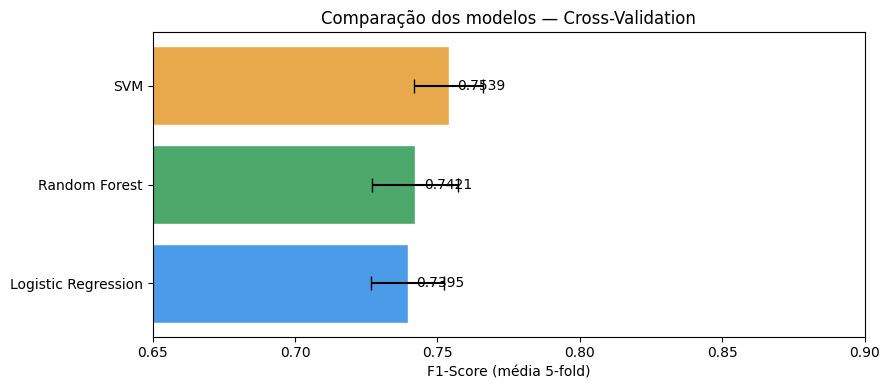

In [12]:
# Comparação visual dos modelos por F1-Score
fig, ax = plt.subplots(figsize=(9, 4))

nomes  = list(resultados.keys())
medias = [resultados[n].mean() for n in nomes]
stds   = [resultados[n].std()  for n in nomes]
cores  = ['#4C9BE8', '#4CA86B', '#E8A84C']

bars = ax.barh(nomes, medias, xerr=stds, color=cores,
               edgecolor='white', capsize=5)
ax.set_xlabel('F1-Score (média 5-fold)')
ax.set_title('Comparação dos modelos — Cross-Validation')
ax.set_xlim(0.65, 0.90)
for bar, media in zip(bars, medias):
    ax.text(media + 0.003, bar.get_y() + bar.get_height()/2,
            f'{media:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Ensemble — Voting Classifier

O VotingClassifier combina as previsões dos três modelos por votação suave (soft voting).  
Soft voting usa a média das probabilidades — mais robusto que hard voting (maioria simples).

| Estratégia | Descrição |
|---|---|
| Hard voting | Cada modelo vota 0 ou 1 — vence a maioria |
| **Soft voting** | Média das probabilidades — mais estável e geralmente superior |

In [13]:
# Pipeline com scaler interno — garante que a normalização seja feita corretamente
# dentro de cada fold do cross-validation, sem data leakage
ensemble = VotingClassifier(
    estimators=[
        ('lr', Pipeline([('scaler', StandardScaler()),
                         ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))])),
        ('rf', Pipeline([('scaler', StandardScaler()),
                         ('clf', RandomForestClassifier(n_estimators=300, random_state=42))])),
        ('svm', Pipeline([('scaler', StandardScaler()),
                          ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))])),
    ],
    voting='soft'  # soft voting — média das probabilidades de cada modelo
)

scores_ensemble = cross_val_score(ensemble, X_train, y, cv=cv, scoring='f1')
print(f'Ensemble (Soft Voting)  F1: {scores_ensemble.mean():.4f} ± {scores_ensemble.std():.4f}')

# Comparação final: melhor modelo individual vs. ensemble
melhor_individual = max(resultados, key=lambda n: resultados[n].mean())
print(f'\nMelhor modelo individual ({melhor_individual}): {resultados[melhor_individual].mean():.4f}')
print(f'Ensemble:                                       {scores_ensemble.mean():.4f}')

Ensemble (Soft Voting)  F1: 0.7590 ± 0.0100

Melhor modelo individual (SVM): 0.7539
Ensemble:                                       0.7590


## 9. Avaliação Final

In [14]:
# Divisão estratificada treino/validação — preserva proporção das classes
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y, test_size=0.2, random_state=42, stratify=y
)

# O scaler interno do Pipeline é fitado apenas em X_tr — sem data leakage
ensemble.fit(X_tr, y_tr)
y_pred = ensemble.predict(X_val)

print(f'F1-Score (validação): {f1_score(y_val, y_pred):.4f}')
print()
print(classification_report(y_val, y_pred,
                             target_names=['Não-desastre', 'Desastre']))

F1-Score (validação): 0.7781

              precision    recall  f1-score   support

Não-desastre       0.81      0.89      0.85       869
    Desastre       0.83      0.73      0.78       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



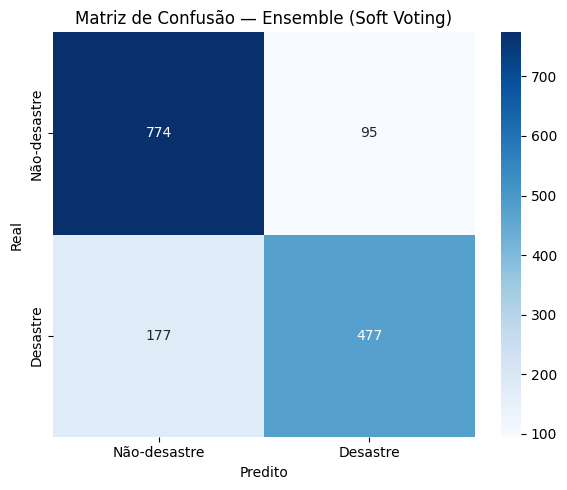

In [15]:
# Matriz de confusão — erros simétricos indicam que o modelo não tem viés por classe
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não-desastre', 'Desastre'],
            yticklabels=['Não-desastre', 'Desastre'])
plt.title('Matriz de Confusão — Ensemble (Soft Voting)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

## 10. Geração do Submission

In [16]:
# Retreina no conjunto completo de treino antes de gerar o submission
ensemble.fit(X_train, y)
predicoes = ensemble.predict(X_test)

submission = pd.DataFrame({
    'id':     test['id'],
    'target': predicoes
})

submission.to_csv('submission.csv', index=False)
print(f'submission.csv salvo — {len(submission)} linhas')
print(submission['target'].value_counts().to_string())

submission.csv salvo — 3263 linhas
target
0    2087
1    1176
